# 📊 Etapa 1: Análise Exploratória de Dados (EDA) - Previsão de Churn
**Autor:** Thiago Soares Simões (RM374443)  
**Objetivo:** Compreender a saúde dos dados da FIAPMobile e identificar padrões que indiquem a saída de clientes.

### Configuração e Reprodutibilidade (Código)
Aqui estamos fazendo imports necessários e fixando a semente (seed) em 42 para garantirmos resultados reproduziveis.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fixando a semente para garantir resultados reproduzíveis
SEED = 42
np.random.seed(SEED)

import warnings
warnings.filterwarnings('ignore')

### Carga de Dados
Nesta etapa, carregamos o dataset Telco Customer Churn para realizar a inspeção inicial 
de tipos e volumes.

In [62]:
# Carga sem tratamentos iniciais para fins de exploração
DATA_PATH = "../data/raw/telco_customer_churn.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape dos dados: {df.shape[0]} registros e {df.shape[1]} colunas")
print(f"\nPrimeiras 10 linhas do dataset:")
df.head(10)

Shape dos dados: 7043 registros e 21 colunas

Primeiras 10 linhas do dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


### Inspeção Estrutural (Discovery)
Utilizaremos o método `df.info()` para mapear os tipos de dados (Dtypes) e a presença 
de valores nulos. Esta etapa é crucial para identificarmos se as variáveis estão 
no formato correto para os modelos de ML.

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Utilizaremos o método `df.describe(include='all')` para analisaremos estatísticas descritivas.
Mostra: `count`, `mean`, `std`, `min`, `25%`, `50%` (mediana), `75%`, `max`.
Útil para entender escala, dispersão e possíveis outliers.

In [64]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


### Análise de Valores Faltantes e Inconsistências
Embora o método `info()` não tenha detectado valores nulos tradicionais (NaN), sabemos que 
campos do tipo `object` podem esconder espaços em branco. Vamos forçar a conversão de 
`TotalCharges` para númerico porque detectamos que ele é do tipo object e contém números e mapear onde os dados realmente faltam.

In [71]:
# Criando uma cópia para não sujar o dataframe original nesta fase de exploração
df_analise = df.copy()

# Forçando a conversão para numérico (espaços viram NaN)
df_analise['TotalCharges'] = pd.to_numeric(df_analise['TotalCharges'], errors='coerce')

# Somando os nulos reais agora
missing_summary = pd.DataFrame({
    'Nulos Reais': df_analise.isnull().sum(),
    'Porcentagem (%)': (df_analise.isnull().sum() / len(df_analise) * 100).round(2)
})

print("Relatório de Dados Faltantes:")
missing_summary[missing_summary['Nulos Reais'] > 0]

Relatório de Dados Faltantes:


,Nulos Reais,Porcentagem (%)
TotalCharges,11,0.16


### Investigação dos Nulos em TotalCharges
Ao quantificarmos 11 valores nulos após a conversão, levantamos a hipótese de que eles 
pertencem a novos clientes. Vamos validar se o `tenure` (meses de casa) desses 
registros é de fato igual a zero.

In [72]:
# Filtrando apenas os registros onde TotalCharges ficou nulo
nulos_total_charges = df_analise[df_analise['TotalCharges'].isnull()]

# Verificando o tempo de casa (tenure) desses clientes
print(f"Meses de casa dos clientes com TotalCharges nulo: {nulos_total_charges['tenure'].unique()}")

print(f"\nInvestigando os {len(nulos_total_charges)} registros:")
display(nulos_total_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

Meses de casa dos clientes com TotalCharges nulo: [0]

Investigando os 11 registros:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


## Analisando o balanceamento da classe alvo (Churn)


Distribuição da Variável Alvo (Churn):


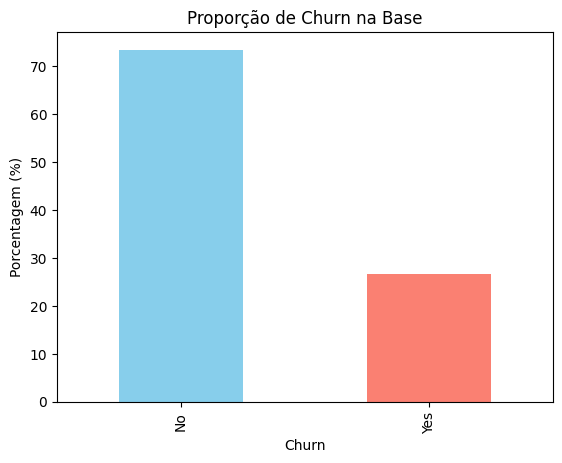

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [75]:
# Analisando o balanceamento da classe alvo
print("Distribuição da Variável Alvo (Churn):")
distribuicao = df['Churn'].value_counts(normalize=True) * 100

# Visualização simples
distribuicao.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Proporção de Churn na Base')
plt.ylabel('Porcentagem (%)')
plt.show()

print(distribuicao)

### 4. Análise da Variável Alvo (Churn)
Identificamos que 26,54% dos clientes da base cancelaram o serviço. Este volume 
indica um desbalanceamento moderado que exige atenção na escolha das métricas.

**Principais conclusões desta análise:**
1. O baseline de acurácia a ser batido é de **73,46%** (Dummy Classifier).
2. A acurácia não será utilizada como métrica única, dado o desbalanceamento.
3. O objetivo de negócio prioriza o **Recall**, visando minimizar a perda de clientes 
não detectados pelo modelo.

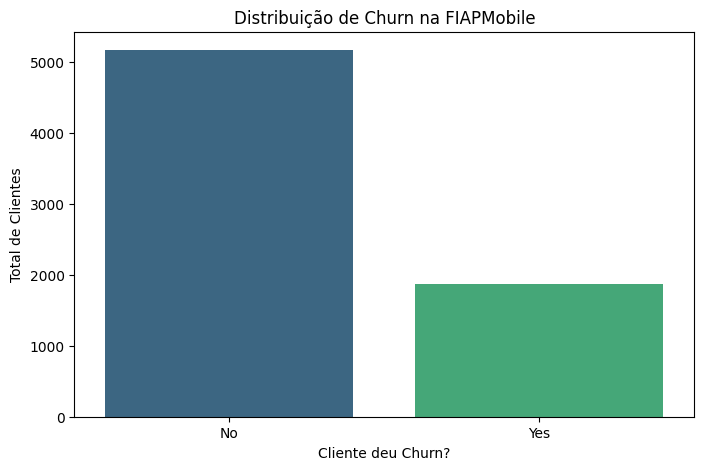

In [78]:
# Verificação visual do desbalanceamento para o relatório
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribuição de Churn na FIAPMobile')
plt.xlabel('Cliente deu Churn?')
plt.ylabel('Total de Clientes')
plt.show()